In [4]:
import sys
from pathlib import Path

# добавляем src/data в путь чтобы импортировать data_base
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 4)

In [5]:
# ── список всех доступных тикеров ────────────────────────────────────────────
daily_dir  = Path("../moex_candles/daily")
hourly_dir = Path("../moex_candles/hourly")

tickers_daily  = sorted(p.stem for p in daily_dir.glob("*.parquet"))
tickers_hourly = sorted(p.stem for p in hourly_dir.glob("*.parquet"))

# берём только те что есть в обоих интервалах
tickers = sorted(set(tickers_daily) & set(tickers_hourly))

print(f"Дневные:  {len(tickers_daily)} тикеров")
print(f"Часовые:  {len(tickers_hourly)} тикеров")
print(f"В обоих:  {len(tickers)} тикеров")
print(f"\nПервые 20: {tickers[:20]}")

Дневные:  260 тикеров
Часовые:  260 тикеров
В обоих:  260 тикеров

Первые 20: ['ABIO', 'ABRD', 'AFKS', 'AFLT', 'AKRN', 'ALRS', 'AMEZ', 'APRI', 'APTK', 'AQUA', 'ARSA', 'ASSB', 'ASTR', 'AVAN', 'BANE', 'BANEP', 'BAZA', 'BELU', 'BISVP', 'BLNG']


In [6]:
# ── загрузка всех датасетов в словари ────────────────────────────────────────
# raw_daily[ticker]  = полный DataFrame дневных свечей
# raw_hourly[ticker] = полный DataFrame часовых свечей

raw_daily  = {}
raw_hourly = {}

for t in tickers:
    raw_daily[t]  = pd.read_parquet(daily_dir  / f"{t}.parquet").sort_values("timestamp").reset_index(drop=True)
    raw_hourly[t] = pd.read_parquet(hourly_dir / f"{t}.parquet").sort_values("timestamp").reset_index(drop=True)

print("Загружено тикеров:", len(raw_daily))
print("\nКолонки (daily):", raw_daily[tickers[0]].columns.tolist())
print("Колонки (hourly):", raw_hourly[tickers[0]].columns.tolist())

# сводная таблица: сколько строк и какой период у каждого тикера
rows = []
for t in tickers:
    d = raw_daily[t]
    h = raw_hourly[t]
    rows.append({
        "ticker":        t,
        "daily_rows":    len(d),
        "daily_from":    d["timestamp"].min().date(),
        "daily_to":      d["timestamp"].max().date(),
        "hourly_rows":   len(h),
        "hourly_from":   h["timestamp"].min().date(),
        "hourly_to":     h["timestamp"].max().date(),
    })

summary = pd.DataFrame(rows).set_index("ticker")
summary

Загружено тикеров: 260

Колонки (daily): ['timestamp', 'open', 'high', 'low', 'close', 'volume']
Колонки (hourly): ['timestamp', 'open', 'high', 'low', 'close', 'volume']


,daily_rows,daily_from,daily_to,hourly_rows,hourly_from,hourly_to
ticker,,,,,,
ABIO,4140,2009-12-11,2026-03-26,30232,2011-11-17,2026-03-06
ABRD,3222,2012-04-11,2026-03-26,23547,2012-04-11,2026-03-06
AFKS,4654,2007-12-12,2026-03-26,43011,2011-11-17,2026-03-06
AFLT,5612,2004-02-13,2026-03-26,43298,2011-11-17,2026-03-06
AKRN,4923,2006-10-20,2026-03-26,35517,2011-11-17,2026-03-06
...,...,...,...,...,...,...
YRSB,2588,2005-11-08,2026-03-26,9660,2011-12-13,2026-03-06
YRSBP,2857,2007-03-12,2026-03-26,11420,2011-12-09,2026-03-06
ZAYM,570,2024-04-12,2026-03-26,8237,2024-04-12,2026-03-06


In [7]:
T_FROM = pd.Timestamp("2015-01-01")
T_TO   = pd.Timestamp("2026-03-06")

# ── фильтрация: оставляем только тикеры у которых есть данные с 2015 ──────────
tickers_ok = [
    t for t in tickers
    if raw_daily[t]["timestamp"].min() <= T_FROM
    and raw_hourly[t]["timestamp"].min() <= T_FROM
]

print(f"Тикеров с данными с {T_FROM.date()}: {len(tickers_ok)} из {len(tickers)}")
print(f"Отброшено: {len(tickers) - len(tickers_ok)}")

# ── обрезка всех df по единому окну [T_FROM, T_TO] ───────────────────────────
daily  = {}
hourly = {}

for t in tickers_ok:
    d = raw_daily[t]
    h = raw_hourly[t]

    daily[t]  = d[(d["timestamp"] >= T_FROM) & (d["timestamp"] <= T_TO)].reset_index(drop=True)
    hourly[t] = h[(h["timestamp"] >= T_FROM) & (h["timestamp"] <= T_TO)].reset_index(drop=True)

# ── сводная таблица после обрезки ─────────────────────────────────────────────
rows = []
for t in tickers_ok:
    d = daily[t]
    h = hourly[t]
    rows.append({
        "ticker":       t,
        "daily_rows":   len(d),
        "daily_from":   d["timestamp"].min().date(),
        "daily_to":     d["timestamp"].max().date(),
        "hourly_rows":  len(h),
        "hourly_from":  h["timestamp"].min().date(),
        "hourly_to":    h["timestamp"].max().date(),
    })

summary_cut = pd.DataFrame(rows).set_index("ticker")
print(f"\nИтого тикеров: {len(summary_cut)}")
summary_cut

Тикеров с данными с 2015-01-01: 192 из 260
Отброшено: 68

Итого тикеров: 192


,daily_rows,daily_from,daily_to,hourly_rows,hourly_from,hourly_to
ticker,,,,,,
ABIO,2869,2015-01-05,2026-03-06,26245,2015-01-05,2026-03-05
ABRD,2571,2015-01-08,2026-03-06,20717,2015-01-08,2026-03-05
AFKS,2883,2015-01-05,2026-03-06,35939,2015-01-05,2026-03-05
AFLT,2883,2015-01-05,2026-03-06,36203,2015-01-05,2026-03-05
AKRN,2863,2015-01-05,2026-03-06,28438,2015-01-05,2026-03-05
...,...,...,...,...,...,...
YKENP,2635,2015-01-16,2026-03-06,13584,2015-01-16,2026-03-05
YRSB,1801,2015-01-14,2026-03-06,9217,2015-01-14,2026-03-05
YRSBP,1950,2015-01-13,2026-03-06,10806,2015-01-13,2026-03-05


In [8]:
# ── эталонные торговые календари ─────────────────────────────────────────────
# берём union всех timestamp по всем тикерам — это все дни/часы когда хоть кто-то торговался

all_daily_ts  = sorted(set().union(*[set(daily[t]["timestamp"])  for t in tickers_ok]))
all_hourly_ts = sorted(set().union(*[set(hourly[t]["timestamp"]) for t in tickers_ok]))

print(f"Эталонный торговый календарь:")
print(f"  Дневные:  {len(all_daily_ts)} торговых дней")
print(f"  Часовые:  {len(all_hourly_ts)} торговых часов")

# ── считаем пропуски для каждого тикера ──────────────────────────────────────
ref_daily_set  = set(all_daily_ts)
ref_hourly_set = set(all_hourly_ts)

rows = []
for t in tickers_ok:
    d_ts = set(daily[t]["timestamp"])
    h_ts = set(hourly[t]["timestamp"])

    d_missing = len(ref_daily_set  - d_ts)
    h_missing = len(ref_hourly_set - h_ts)

    rows.append({
        "ticker":           t,
        "daily_total":      len(ref_daily_set),
        "daily_present":    len(d_ts),
        "daily_missing":    d_missing,
        "daily_miss_%":     round(d_missing / len(ref_daily_set) * 100, 2),
        "hourly_total":     len(ref_hourly_set),
        "hourly_present":   len(h_ts),
        "hourly_missing":   h_missing,
        "hourly_miss_%":    round(h_missing / len(ref_hourly_set) * 100, 2),
    })

miss_df = pd.DataFrame(rows).set_index("ticker")

# ── сводная статистика ────────────────────────────────────────────────────────
print("\n── Статистика пропусков (%) ──────────────────────────────")
print(miss_df[["daily_miss_%", "hourly_miss_%"]].describe().round(2))

miss_df

Эталонный торговый календарь:
  Дневные:  2883 торговых дней
  Часовые:  36258 торговых часов

── Статистика пропусков (%) ──────────────────────────────
       daily_miss_%  hourly_miss_%
count        192.00         192.00
mean          10.11          39.09
std           15.55          24.65
min            0.00           0.00
25%            0.42          19.28
50%            4.74          42.18
75%           13.04          59.91
max           99.90          99.99


,daily_total,daily_present,daily_missing,daily_miss_%,hourly_total,hourly_present,hourly_missing,hourly_miss_%
ticker,,,,,,,,
ABIO,2883,2869,14,0.49,36258,26245,10013,27.62
ABRD,2883,2571,312,10.82,36258,20717,15541,42.86
AFKS,2883,2883,0,0.00,36258,35939,319,0.88
AFLT,2883,2883,0,0.00,36258,36203,55,0.15
AKRN,2883,2863,20,0.69,36258,28438,7820,21.57
...,...,...,...,...,...,...,...,...
YKENP,2883,2635,248,8.60,36258,13584,22674,62.54
YRSB,2883,1801,1082,37.53,36258,9217,27041,74.58
YRSBP,2883,1950,933,32.36,36258,10806,25452,70.20


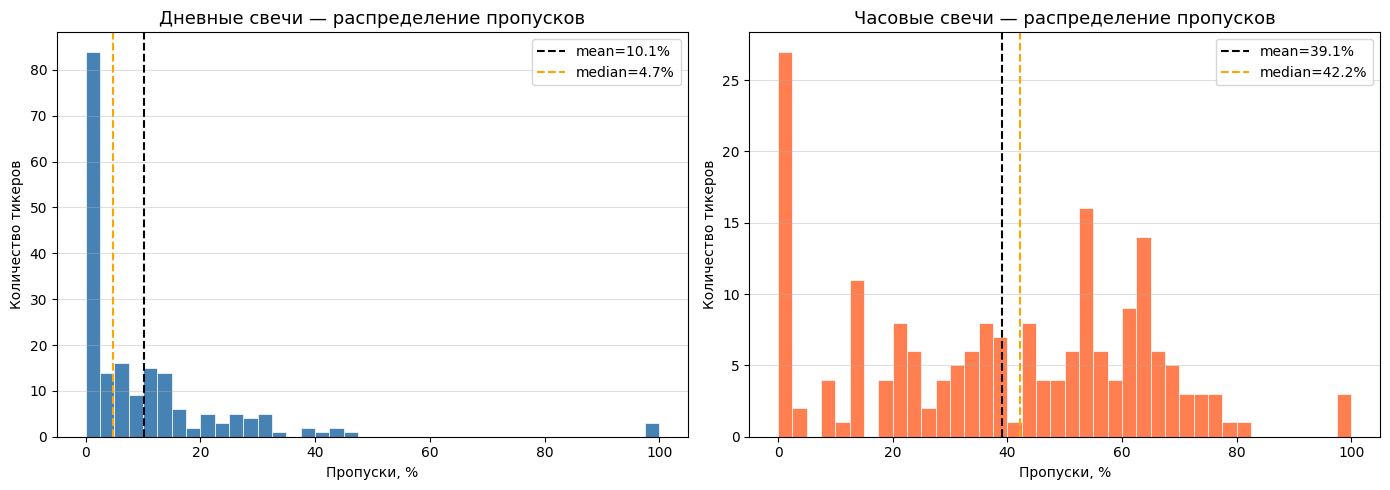

Топ-10 по дневным пропускам:
ticker
GAZS     99.90
GAZC     99.86
GAZT     99.86
KGKCP    45.09
KGKC     44.92
RDRB     44.75
MGNZ     39.99
PRMB     39.82
YRSB     37.53
RUSI     34.51

Топ-10 по часовым пропускам:
ticker
GAZC     99.99
GAZS     99.99
GAZT     99.99
PRMB     81.70
RTGZ     79.25
MGNZ     77.02
KCHEP    75.48
KRKN     75.08
YRSB     74.58
VSYDP    74.05


In [9]:
# ── визуализация распределения пропусков ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, color in zip(
    axes,
    ["daily_miss_%", "hourly_miss_%"],
    ["Дневные свечи", "Часовые свечи"],
    ["steelblue", "coral"],
):
    data_col = miss_df[col]

    ax.hist(data_col, bins=40, color=color, edgecolor="white", linewidth=0.5)
    ax.axvline(data_col.mean(),   color="black",  linestyle="--", linewidth=1.5, label=f"mean={data_col.mean():.1f}%")
    ax.axvline(data_col.median(), color="orange",  linestyle="--", linewidth=1.5, label=f"median={data_col.median():.1f}%")

    ax.set_title(f"{title} — распределение пропусков", fontsize=13)
    ax.set_xlabel("Пропуски, %")
    ax.set_ylabel("Количество тикеров")
    ax.legend()
    ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

# ── топ-10 тикеров с наибольшими пропусками ───────────────────────────────────
print("Топ-10 по дневным пропускам:")
print(miss_df["daily_miss_%"].nlargest(10).to_string())
print("\nТоп-10 по часовым пропускам:")
print(miss_df["hourly_miss_%"].nlargest(10).to_string())

Тикеров с дневными пропусками < 5%:  98
Тикеров с дневными пропусками < 10%: 123


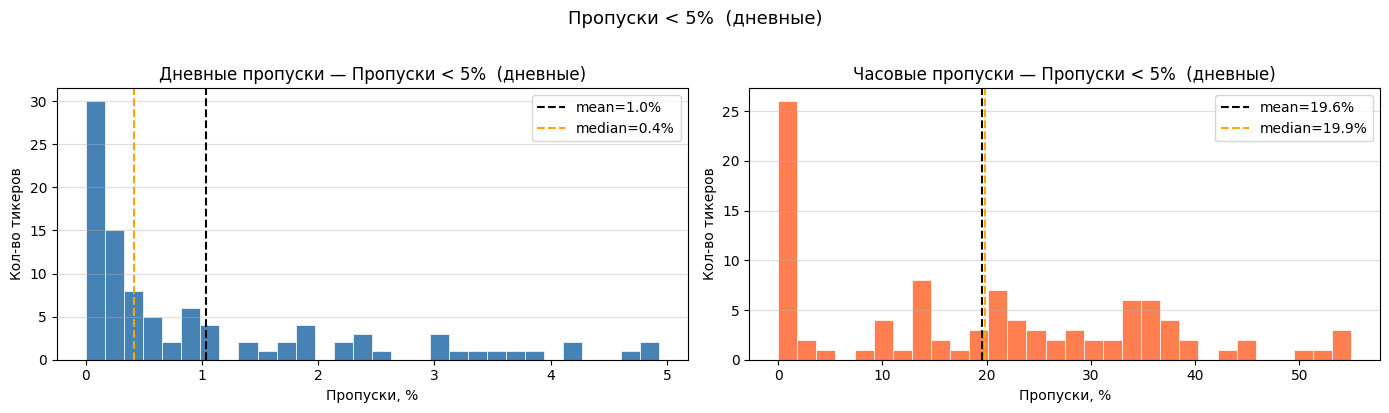

       daily_miss_%  hourly_miss_%
count         98.00          98.00
mean           1.04          19.59
std            1.30          15.96
min            0.00           0.00
25%            0.09           1.68
50%            0.42          19.87
75%            1.70          33.82
max            4.93          54.98



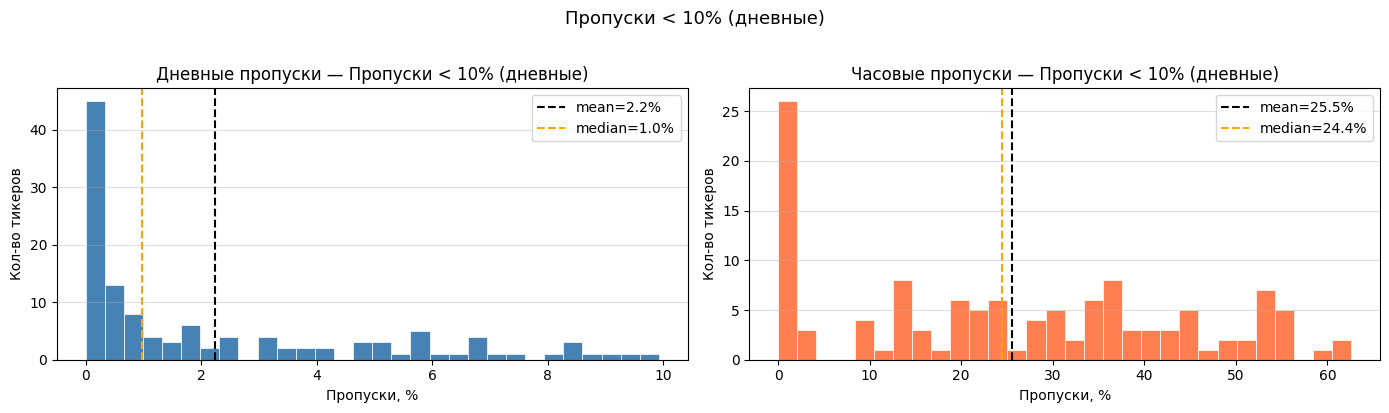

       daily_miss_%  hourly_miss_%
count        123.00         123.00
mean           2.25          25.50
std            2.75          18.87
min            0.00           0.00
25%            0.21           9.48
50%            0.97          24.42
75%            3.73          39.04
max            9.92          62.61



In [10]:
# ── фильтрация по порогам дневных пропусков ──────────────────────────────────
miss_5pct  = miss_df[miss_df["daily_miss_%"] < 5].copy()
miss_10pct = miss_df[miss_df["daily_miss_%"] < 10].copy()

print(f"Тикеров с дневными пропусками < 5%:  {len(miss_5pct)}")
print(f"Тикеров с дневными пропусками < 10%: {len(miss_10pct)}")

# ── функция для построения графика пропусков ─────────────────────────────────
def plot_missing(df: pd.DataFrame, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, col, label, color in zip(
        axes,
        ["daily_miss_%", "hourly_miss_%"],
        ["Дневные", "Часовые"],
        ["steelblue", "coral"],
    ):
        s = df[col]
        ax.hist(s, bins=30, color=color, edgecolor="white", linewidth=0.5)
        ax.axvline(s.mean(),   color="black",  linestyle="--", lw=1.5, label=f"mean={s.mean():.1f}%")
        ax.axvline(s.median(), color="orange", linestyle="--", lw=1.5, label=f"median={s.median():.1f}%")
        ax.set_title(f"{label} пропуски — {title}")
        ax.set_xlabel("Пропуски, %")
        ax.set_ylabel("Кол-во тикеров")
        ax.legend()
        ax.grid(axis="y", alpha=0.4)
    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    print(df[["daily_miss_%", "hourly_miss_%"]].describe().round(2))
    print()

plot_missing(miss_5pct,  "Пропуски < 5%  (дневные)")
plot_missing(miss_10pct, "Пропуски < 10% (дневные)")

In [26]:
# ── запись словарей с пропусками в tickers.py ────────────────────────────────
tickers_py_path = Path("../tickers.py")

daily_miss_dict  = miss_df["daily_miss_%"].round(2).to_dict()
hourly_miss_dict = miss_df["hourly_miss_%"].round(2).to_dict()

# форматируем словарь в читаемый вид
def fmt_dict(d: dict, name: str) -> str:
    lines = [f"{name} = {{"]
    for k, v in sorted(d.items()):
        lines.append(f'    "{k}": {v},')
    lines.append("}")
    return "\n".join(lines)

block = "\n\n".join([
    "# ── процент пропусков по тикерам (относительно эталонного торгового календаря) ──",
    fmt_dict(daily_miss_dict,  "DAILY_MISSING_PCT"),
    fmt_dict(hourly_miss_dict, "HOURLY_MISSING_PCT"),
])

# читаем текущий tickers.py и дописываем в конец
original = tickers_py_path.read_text(encoding="utf-8").rstrip()

# убираем старый блок если уже есть
marker = "# ── процент пропусков"
if marker in original:
    original = original[:original.index(marker)].rstrip()

new_content = original + "\n\n\n" + block + "\n"
tickers_py_path.write_text(new_content, encoding="utf-8")

print("Записано в tickers.py:")
print(f"  DAILY_MISSING_PCT  — {len(daily_miss_dict)} тикеров")
print(f"  HOURLY_MISSING_PCT — {len(hourly_miss_dict)} тикеров")
print(f"\nПример (первые 5):")
for t in list(daily_miss_dict)[:5]:
    print(f"  {t}: daily={daily_miss_dict[t]}%  hourly={hourly_miss_dict[t]}%")

Записано в tickers.py:
  DAILY_MISSING_PCT  — 192 тикеров
  HOURLY_MISSING_PCT — 192 тикеров

Пример (первые 5):
  ABIO: daily=0.49%  hourly=27.62%
  ABRD: daily=10.82%  hourly=42.86%
  AFKS: daily=0.0%  hourly=0.88%
  AFLT: daily=0.0%  hourly=0.15%
  AKRN: daily=0.69%  hourly=21.57%


In [29]:
import requests
import time

# ── официальный маппинг отраслевых индексов MOEX → сектор ────────────────────
# Источник: https://www.moex.com/a601
SECTOR_INDEX_MAP = {
    "MOEXOG":  "Нефть и газ",
    "RTSog":   "Нефть и газ",
    "MOEXFN":  "Финансы",
    "RTSfn":   "Финансы",
    "MOEXMM":  "Металлургия и добыча",
    "RTSmm":   "Металлургия и добыча",
    "MOEXIT":  "Информационные технологии",
    "RTSit":   "Информационные технологии",
    "MOEXCN":  "Потребительский сектор",
    "RTScr":   "Потребительский сектор",
    "MOEXTL":  "Телекоммуникации",        # актуальный код
    "MOEXTLC": "Телекоммуникации",        # старый код
    "RTStl":   "Телекоммуникации",
    "MOEXCH":  "Химия и нефтехимия",
    "RTSch":   "Химия и нефтехимия",
    "MOEXEU":  "Электроэнергетика",       # актуальный код
    "MOEXPW":  "Электроэнергетика",       # старый код
    "RTSeu":   "Электроэнергетика",
    "RTSut":   "Электроэнергетика",
    "MOEXRE":  "Строительство и девелопмент",
    "RTSre":   "Строительство и девелопмент",
    "MOEXTN":  "Транспорт",               # актуальный код
    "MOEXTRN": "Транспорт",               # старый код
    "RTStn":   "Транспорт",
}

def get_ticker_sector(ticker: str, session: requests.Session) -> str | None:
    """
    Запрашивает список индексов для тикера через /securities/{ticker}/indices.json
    и возвращает сектор по первому найденному отраслевому индексу.
    """
    url = f"https://iss.moex.com/iss/securities/{ticker}/indices.json"
    try:
        r = session.get(url, params={"iss.meta": "off"}, timeout=10)
        if r.status_code != 200:
            return None
        block = r.json().get("indices", {})
        cols  = block.get("columns", [])
        rows  = block.get("data", [])
        if not cols or not rows:
            return None
        secid_col = cols.index("SECID") if "SECID" in cols else 0
        ticker_indices = [row[secid_col] for row in rows]
        # ищем первый отраслевой индекс
        for idx in ticker_indices:
            if idx in SECTOR_INDEX_MAP:
                return SECTOR_INDEX_MAP[idx]
    except Exception:
        pass
    return None


session = requests.Session()
print(f"Запрашиваю сектора для {len(tickers_ok)} тикеров через /securities/{{ticker}}/indices.json ...")
print("(~1 запрос на тикер, займёт ~30-60 сек)\n")

ticker_to_sector: dict[str, str] = {}
no_sector = []

for i, ticker in enumerate(tickers_ok):
    sector = get_ticker_sector(ticker, session)
    if sector:
        ticker_to_sector[ticker] = sector
    else:
        no_sector.append(ticker)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(tickers_ok)} обработано, найдено секторов: {len(ticker_to_sector)}")
    time.sleep(0.05)

print(f"\nНайдено секторов: {len(ticker_to_sector)} / {len(tickers_ok)}")
print(f"Без сектора: {len(no_sector)} тикеров → будут помечены как 'Прочее'")
if no_sector:
    print("  Примеры:", no_sector[:20])

# ── итоговый DataFrame ────────────────────────────────────────────────────────
sectors_df = pd.DataFrame({
    "sector": {t: ticker_to_sector.get(t, "Прочее") for t in tickers_ok}
})

print("\nРаспределение по секторам:")
print(sectors_df["sector"].value_counts().to_string())
sectors_df

Запрашиваю сектора для 192 тикеров через /securities/{ticker}/indices.json ...
(~1 запрос на тикер, займёт ~30-60 сек)

  50/192 обработано, найдено секторов: 26
  100/192 обработано, найдено секторов: 56
  150/192 обработано, найдено секторов: 81

Найдено секторов: 96 / 192
Без сектора: 96 тикеров → будут помечены как 'Прочее'
  Примеры: ['ABRD', 'ARSA', 'ASSB', 'AVAN', 'BRZL', 'CHGZ', 'CHKZ', 'DIOD', 'DZRD', 'DZRDP', 'GAZA', 'GAZAP', 'GAZC', 'GAZS', 'GAZT', 'HIMCP', 'IGST', 'IGSTP', 'IRKT', 'JNOS']

Распределение по секторам:
sector
Прочее                         96
Электроэнергетика              23
Металлургия и добыча           19
Нефть и газ                    16
Телекоммуникации                9
Потребительский сектор          8
Химия и нефтехимия              8
Финансы                         7
Транспорт                       4
Строительство и девелопмент     2


,sector
ABIO,Потребительский сектор
ABRD,Прочее
AFKS,Финансы
AFLT,Транспорт
AKRN,Химия и нефтехимия
...,...
YKENP,Прочее
YRSB,Прочее
YRSBP,Прочее
ZILL,Прочее


In [ ]:
# ── визуализация распределения по секторам ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
counts = sectors_df["sector"].value_counts()
counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Количество тикеров")
ax.set_title("Распределение тикеров по секторам (MOEX отраслевая классификация)")
ax.invert_yaxis()
for i, v in enumerate(counts):
    ax.text(v + 0.3, i, str(v), va="center")
plt.tight_layout()
plt.show()

print("\nТикеры без сектора ('Прочее'):")
print(sectors_df[sectors_df["sector"] == "Прочее"].index.tolist())

Получаю OKVED для тикеров не покрытых индексами...
  Нужно обработать: 156 тикеров
  30/156...
  60/156...
  90/156...
  120/156...
  150/156...

Распределение по секторам:
sector
Прочее                         156
Металлургия и добыча            12
Нефть и газ                     10
Финансы                          5
Химия и нефтехимия               4
Потребительский сектор           3
Строительство и девелопмент      2


,sector,okved
ABIO,Прочее,
ABRD,Прочее,
AFKS,Прочее,
AFLT,Прочее,
AKRN,Химия и нефтехимия,
...,...,...
YKENP,Прочее,
YRSB,Прочее,
YRSBP,Прочее,
ZILL,Прочее,


In [ ]:
# ── объединяем miss_df с секторами ───────────────────────────────────────────
miss_with_sector = miss_df.join(sectors_df[["sector"]], how="left")
miss_with_sector["sector"] = miss_with_sector["sector"].fillna("Прочее")

print("Средние пропуски по секторам (дневные):")
print(
    miss_with_sector.groupby("sector")[["daily_miss_%", "hourly_miss_%"]]
    .mean().round(2)
    .sort_values("daily_miss_%")
    .to_string()
)

miss_with_sector